In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
car_data = pd.read_csv('used_cars_dataset.csv')
car_data.head()


,name,year,km_driven,fuel,seller_type,transmission,owner,selling_price
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner,60000
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner,135000
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner,600000
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner,250000
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner,450000


In [27]:
print("\n*** USED CAR DATASET INFO ***")
print(car_data.info())

print("\n*** USED CAR DATASET DESCRIPTION ***")
print(car_data.describe())

print("\n*** UNIQUE VALUES PER COLUMN ***")
for col in car_data.columns:
    print(f"{col}: {car_data[col].nunique()} unique values")


*** USED CAR DATASET INFO ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   km_driven      4340 non-null   int64 
 3   fuel           4340 non-null   object
 4   seller_type    4340 non-null   object
 5   transmission   4340 non-null   object
 6   owner          4340 non-null   object
 7   selling_price  4340 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None

*** USED CAR DATASET DESCRIPTION ***
              year      km_driven  selling_price
count  4340.000000    4340.000000   4.340000e+03
mean   2013.090783   66215.777419   5.041273e+05
std       4.215344   46644.102194   5.785487e+05
min    1992.000000       1.000000   2.000000e+04
25%    2011.000000   35000.000000   2.087498e+05
50%    2014.000000   60000.000000   3.500000

In [28]:
X = car_data[['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']]
y = car_data['selling_price']

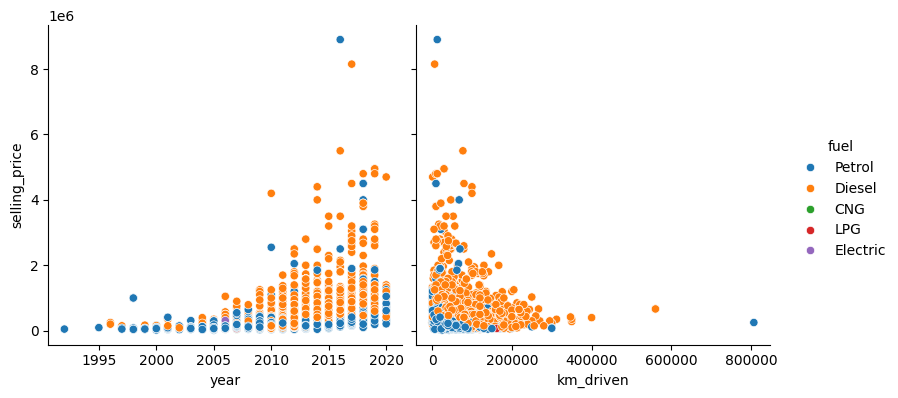

In [29]:
sns.pairplot(
    data=car_data,
    x_vars=['year', 'km_driven'],
    y_vars=['selling_price'],
    hue='fuel',
    height=4,
    aspect=1
)
plt.show()


In [30]:
numeric_cols = ['year', 'km_driven']
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_preprocessed = preprocessor.fit_transform(X)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)


In [32]:
model_car = LinearRegression()
model_car.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model_car.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📊 REGRESSION EVALUATION METRICS (USED CAR PRICE PREDICTION)")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 REGRESSION EVALUATION METRICS (USED CAR PRICE PREDICTION)
Mean Absolute Error (MAE): 221706.3693
Mean Squared Error (MSE): 182146878750.2809
Root Mean Squared Error (RMSE): 426786.6900
R² Score: 0.4031


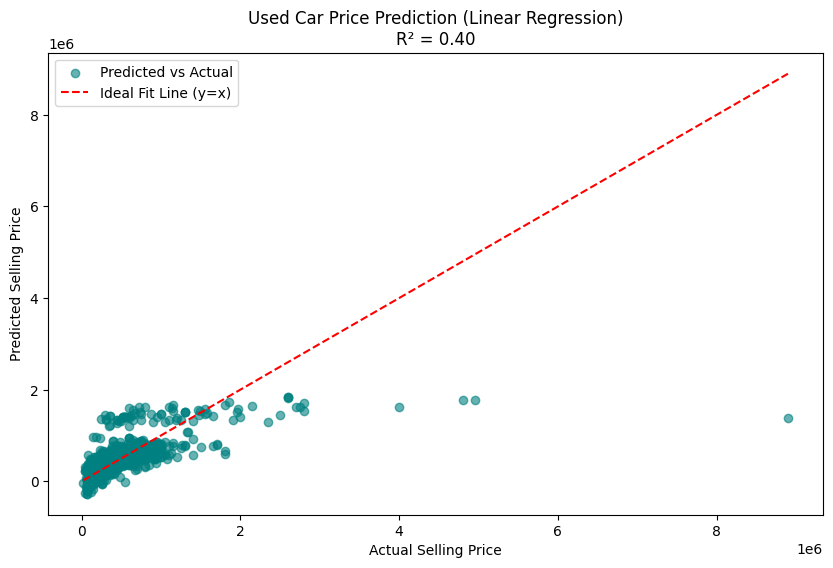

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit Line (y=x)')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title(f'Used Car Price Prediction (Linear Regression)\nR² = {r2:.2f}')
plt.legend()
plt.show()